## Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.cluster import KMeans

## Load Dataset


In [5]:
data=pd.read_csv(r"C:\Users\BVAYA\Desktop\LPU\5th Semster\INT374 Data Analysis with Power BI\Project\Airline+Passenger+Satisfaction\airline_passenger_satisfaction.csv")

In [6]:
data.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

## Data Cleaning

In [9]:
data.dropna() # Dropping null rows
data.fillna(data.median(numeric_only=True), inplace=True) # Handling missing values

## Encoding Target Variables

In [11]:
data['Satisfaction'] = data['Satisfaction'].map({'Satisfied':1,'Neutral or Dissatisfied':0})

## Encoding Categorical Features

In [13]:
categorical_cols = data.select_dtypes(include = ['object']).columns

le=LabelEncoder()
for col in categorical_cols:
    data[col]=le.fit_transform(data[col])

## Classification Model - split data

In [15]:
x=data.drop('Satisfaction',axis=1);
y=data['Satisfaction']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## Feature Scaling

In [21]:
scaler = StandardScaler()

x_trains = scaler.fit_transform(x_train)
x_tests = scaler.transform(x_test)

## Logistic Regression

In [24]:
lr=LogisticRegression(max_iter=1000)
lr.fit(x_trains,y_train)

y_pred_lr = lr.predict(x_tests)

print("Logistic Regression Accuracy : ",accuracy_score(y_test,y_pred_lr))

Logistic Regression Accuracy :  0.8746920234062211


## Random Forest

In [26]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_trains,y_train)

y_pred_rf = rf.predict(x_tests)

print("Random Forest Accuracy : ",accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy :  0.9633122882660918


## Confusion Matrixx

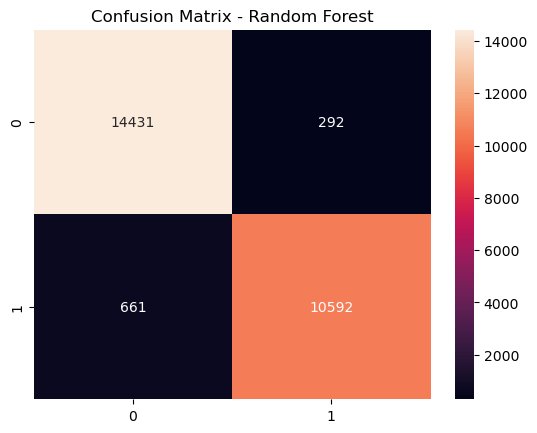

In [27]:
cm = confusion_matrix(y_test,y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Feature Importance

                    Feature  Importance
12          Online Boarding    0.164165
20   In-flight Wifi Service    0.143014
5                     Class    0.109039
4            Type of Travel    0.086439
21  In-flight Entertainment    0.058113
15             Seat Comfort    0.045726
16         Leg Room Service    0.037832
10   Ease of Online Booking    0.036690
3             Customer Type    0.035048
6           Flight Distance    0.032786


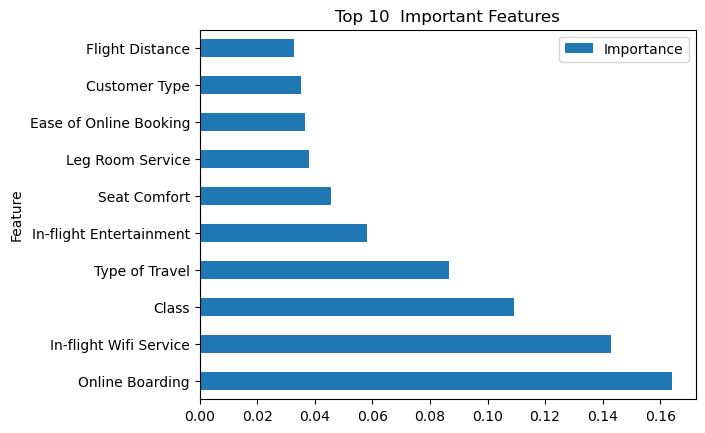

In [31]:
importance =rf.feature_importances_

feature_importance = pd.DataFrame({'Feature' : x.columns,'Importance' : importance}).sort_values(by='Importance',ascending=False)

print(feature_importance.head(10))

#Plotting 
feature_importance.head(10).plot(x='Feature',y='Importance',kind='barh')
plt.title("Top 10  Important Features")
plt.show()

## Regression Model

In [33]:
data['Satisfaction_score'] = data.drop('Satisfaction', axis=1).mean(axis=1) # creating a contiuous target 

x_reg = data.drop(['Satisfaction', 'Satisfaction_score'],axis=1)
y_reg = data['Satisfaction_score']

x_train_r,x_test_r,y_train_r,y_test_r = train_test_split(x_reg,y_reg,test_size=0.2,random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100)
rf_reg.fit(x_train_r,y_train_r)

print("Regression Score :",rf_reg.score(x_test_r,y_test_r))

Regression Score : 0.9999967420756007


## K-Means Clustering

In [36]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

# Apply K-Means

Kmeans = KMeans(n_clusters= 3, random_state = 42)
data['Cluster'] = Kmeans.fit_predict(x_scaled)

print(data['Cluster'].value_counts())

Cluster
0    53425
2    40285
1    36170
Name: count, dtype: int64


In [38]:
# Adding predictions
data['Predicted_Satisfaction'] = rf.predict(x)
# Saving the file
data.to_csv("final_airline_with_predictions.csv", index=False)

C:\Users\BVAYA\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
